# Basit Doğrusal Regresyon

Temel amaç, bağımlı ve bağımsız değişken arasındaki ilişkiyi ifade eden doğrusal fonksiyonu bulmaktır

In [3]:
import pandas as pd
import numpy as np

ad = pd.read_csv("Advertising.csv") # bu veriseti: tv,radyo,gazetelere yapılan reklam harcamaları ve satışı miktarını gösterir

df = ad.copy()

df

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


In [4]:
# indexleri de değişken olarak aldığı için o sütunu siledebiliriz böyle de yapabiliriz:

df = df.iloc[:, 1:len(df)]

df

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
TV,200.0,147.0425,85.854236,0.7,74.375,149.75,218.825,296.4
radio,200.0,23.2640,14.846809,0.0,9.975,22.90,36.525,49.6
newspaper,200.0,30.5540,21.778621,0.3,12.750,25.75,45.100,114.0
sales,200.0,14.0225,5.217457,1.6,10.375,12.90,17.400,27.0


In [7]:
df.isnull().value_counts() # hiç null değer yok

TV     radio  newspaper  sales
False  False  False      False    200
Name: count, dtype: int64

In [8]:
df.corr() 

# değişkenlerin birbirleriyle olan korelasyonlarını(ilişkilerini) inceliyoruz ve anlıyoruz ki satışı en etkileyen tv reklamları
# en az etkileyen de gazete. sıralama şöyle TV>Radio>Newspaper

,TV,radio,newspaper,sales
TV,1.000000,0.054809,0.056648,0.782224
radio,0.054809,1.000000,0.354104,0.576223
newspaper,0.056648,0.354104,1.000000,0.228299
sales,0.782224,0.576223,0.228299,1.000000


C:\Users\since\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\since\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\since\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\since\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

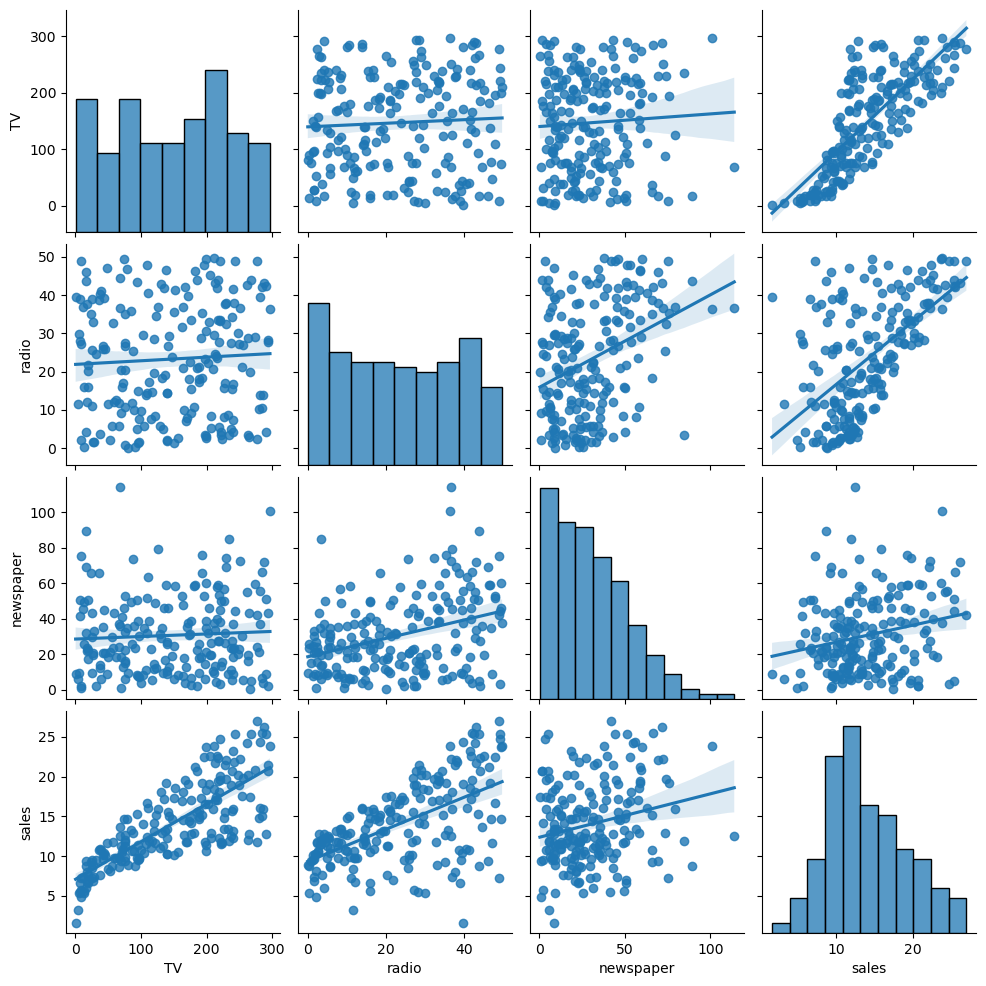

In [9]:
import seaborn as sns
sns.pairplot(df, kind = "reg"); # tüm değişkenlerin birbirleriyle olan ilişkilerini regresyon özelinde gösterir

C:\Users\since\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\since\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


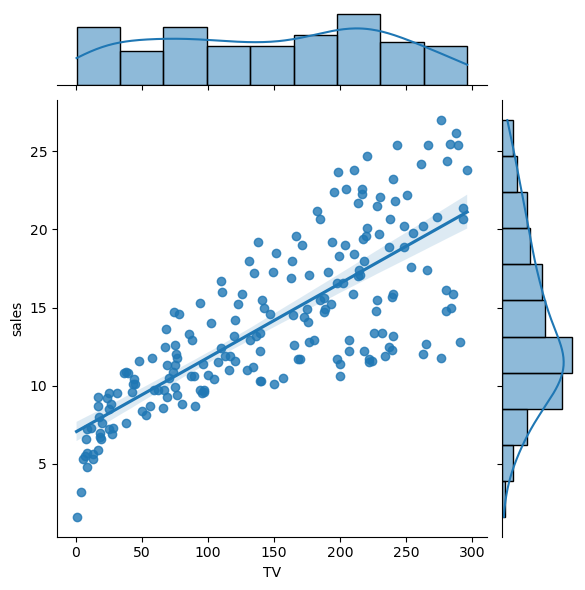

In [10]:
sns.jointplot(x="TV", y="sales", data=df, kind="reg"); # burada tv ile satışların regresyonunu inceliyoruz

## Statsmodels ile modelleme

In [12]:
import statsmodels.api as sm

In [13]:
X = df[["TV"]]
X

,TV
0,230.1
1,44.5
2,17.2
3,151.5
4,180.8
...,...
195,38.2
196,94.2
197,177.0
198,283.6


In [14]:
X = sm.add_constant(X) # elimizdeki x matrisine matris işlemleri yapabilemk için bir '1' ifadesi ekliyoruz

In [15]:
X

,const,TV
0,1.0,230.1
1,1.0,44.5
2,1.0,17.2
3,1.0,151.5
4,1.0,180.8
...,...,...
195,1.0,38.2
196,1.0,94.2
197,1.0,177.0
198,1.0,283.6


In [16]:
y = df[["sales"]]
y

,sales
0,22.1
1,10.4
2,9.3
3,18.5
4,12.9
...,...
195,7.6
196,9.7
197,12.8
198,25.5


In [17]:
lm = sm.OLS(y,X) # model kurduk ve bu modeli lm(lineer model) diye bir değişkene atadık

In [18]:
model = lm.fit() # modeli fit ettik

In [19]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sales   R-squared:                       0.612
Model:                            OLS   Adj. R-squared:                  0.610
Method:                 Least Squares   F-statistic:                     312.1
Date:                Sun, 13 Jul 2025   Prob (F-statistic):           1.47e-42
Time:                        18:12:02   Log-Likelihood:                -519.05
No. Observations:                 200   AIC:                             1042.
Df Residuals:                     198   BIC:                             1049.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.0326      0.458     15.360      0.000       6.130       7.935
TV             0.0475      0.003     17.668      0.000       0.042       0.053
==============================================================================
Omnibus:                        0.531   Durbin-Watson:                   1.935
Prob(Omnibus):                  0.767   Jarque-Bera (JB):                0.669
Skew:                          -0.089   Prob(JB):                        0.716
Kurtosis:                       2.779   Cond. No.                         338.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [20]:
"""
Mülakatlarda böyle bir çıktı verilir ve bu sonuçların yorumlanması istenir. O kadar önemli bu yani.

oluşturulan modelin bilgileri.
bu geniş çaplı çıktıyı sckit-learn ile alamıyoruz. istatistiksel modelleme(statsmodels) ile alıyoruz
bu tarz istatistiksel modelleme işlerinde detayların ne kadar çok olmasıın istyorsak o kadar statsmodels kullanmalıyız
sckit-learn çok geniş kapsamlı modelleme imkanı sunsada, modelin, parametrelerin, istatistiklerin anlamlılığını incelemek için bunu kullannmalıyız.

Method: en küçük kareler methodu imiş

R-squared (R kare): Açıklanabilirlik oranıdır. Bağımsız değişkenin, bağımlı değişkendeki değişkenliğini aaçıklama başarısıdır. 
Yani burada: TV değişkeninin satış değişkeninde yer alan değişkenliğin %61'inı açıklayabilmektedir. 

Adj. R-squared (Düzeltilmiş r kare değeri): R^2'nin duyarlılığı daha az halidir.
R^2 değeri, modele ne kadar değişken eklersek o kadar şişmeye meyillidir. Dolayısıyla modelde anlamlı anlamsız değişken sayısı arttıkça 
r^2 artacaktır. yani r^2 nin artması kötü birşeydir, azalması gerekmektedir. Dolayısıyla Adj. R-squared değeri bizim için daha düzgün bir değerdir

F-statistic: modelin anlamlılığını ölçen bir test istatistiğidir. "Bu model anlamlı mı?" sorusuna yanıttır

Prob (F-statistic) : modelin anlamlılığına yönelik istatistiğin p-value değeridir. burada bu p-value değeri incelenince model anlamlıdır deriz


bu sonucun en önemli yeri:
	   coef	    std err	  t	    P>|t|	[0.025	0.975]
const  7.0326	0.458	15.360	0.000	6.130	7.935
TV	   0.0475	0.003	17.668	0.000	0.042	0.053
Linear Regression'un teorik bölümünde b0 ve b1 değerlerinden bahsetmiştik. b0 değeri, burada coef olarak ifade edilen 7.0326 değeridir.
* b0: 7.0326 ve 0.0475
* p-value: 0.000 ve 0.000 (yani anlamlı her ikisi de)
- yani bize şunu diyor: TV'nin 0.0475 katsayısı, %95 güven oranında 0.042	0.053 bu aralıkta yer alacaktır diyor.
- Ayrıyeten bu tablodan genel yorum: 
   * coef(b0), eğrinin y eksenini kestiği noktadır. yani, diğer değişkenlerde hiçbir değişiklik olmadığında, 
satışlarda olması gereken  ortalama satış miktarı 7.0326'tür. 
   * TV değeri: TV harcamalarında 1 birimlik artış olduğunda, satışlarda 0.0475 kadar artış beklenir. 

Özet olarak: bu bizim doğrusal regresyon tahmin formülümüz vardı y = b0 + b1*x1 diye. heh burada tablonun sonucunda şu ifade ortaya çıkar:
y = 7.0326 + 0.0475 * TVye_Harcanan_Birim
yani doğrusal regresyon tahmin modelimizi kurduk ve artık geleceği tahmin etmeye hazırız!
"""

'\nMülakatlarda böyle bir çıktı verilir ve bu sonuçların yorumlanması istenir. O kadar önemli bu yani.\n\noluşturulan modelin bilgileri.\nbu geniş çaplı çıktıyı sckit-learn ile alamıyoruz. istatistiksel modelleme(statsmodels) ile alıyoruz\nbu tarz istatistiksel modelleme işlerinde detayların ne kadar çok olmasıın istyorsak o kadar statsmodels kullanmalıyız\nsckit-learn çok geniş kapsamlı modelleme imkanı sunsada, modelin, parametrelerin, istatistiklerin anlamlılığını incelemek için bunu kullannmalıyız.\n\nMethod: en küçük kareler methodu imiş\n\nR-squared (R kare): Açıklanabilirlik oranıdır. Bağımsız değişkenin, bağımlı değişkendeki değişkenliğini aaçıklama başarısıdır. \nYani burada: TV değişkeninin satış değişkeninde yer alan değişkenliğin %61\'inı açıklayabilmektedir. \n\nAdj. R-squared (Düzeltilmiş r kare değeri): R^2\'nin duyarlılığı daha az halidir.\nR^2 değeri, modele ne kadar değişken eklersek o kadar şişmeye meyillidir. Dolayısıyla modelde anlamlı anlamsız değişken sayısı artt

In [21]:
import statsmodels.formula.api as smf

lm = smf.ols("sales ~ TV", df)

model = lm.fit()

model.summary()

# yukarıdaki  
# import statsmodels.api as sm    
# lm = sm.OLS(y,X)
# model = lm.fit()
# model.summary()
# işleminin aynısını böyle de yapabiliriz. bir şey değişmiyor. Yazım farklılığı var, ("sales ~ TV", df) değişkenleri böyle yazmak istersek bunu kullan

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sales   R-squared:                       0.612
Model:                            OLS   Adj. R-squared:                  0.610
Method:                 Least Squares   F-statistic:                     312.1
Date:                Sun, 13 Jul 2025   Prob (F-statistic):           1.47e-42
Time:                        18:12:02   Log-Likelihood:                -519.05
No. Observations:                 200   AIC:                             1042.
Df Residuals:                     198   BIC:                             1049.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.0326      0.458     15.360      0.000       6.130       7.935
TV             0.0475      0.003     17.668      0.000       0.042       0.053
==============================================================================
Omnibus:                        0.531   Durbin-Watson:                   1.935
Prob(Omnibus):                  0.767   Jarque-Bera (JB):                0.669
Skew:                          -0.089   Prob(JB):                        0.716
Kurtosis:                       2.779   Cond. No.                         338.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [22]:
model.params # modelin parametreleri geldi. b0 ve b1 değerlerinin sonucunda öğrendiğimiz şeyler

Intercept    7.032594
TV           0.047537
dtype: float64

In [23]:
model.summary().tables[1] # yukarıdaki summary içerisinde 3 adet tablo bulunuyor, ortadakini katsayılar tablosunu getir dedik

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,7.0326,0.458,15.360,0.000,6.130,7.935
TV,0.0475,0.003,17.668,0.000,0.042,0.053


In [24]:
model.conf_int() # confidence interval = güven aralığı demektir. yani katsayıların güven aralıklarını getirdi

,0,1
Intercept,6.129719,7.935468
TV,0.042231,0.052843


In [25]:
model.f_pvalue # modelin anlamlılığına ilişkin p-value değerine erişmek istersek de böyle

1.467389700194647e-42

In [26]:
model.fvalue

312.144994372713

In [27]:
model.tvalues[0:1] # katsayılar değişken değerleriyle çarpılacak ve tahmin değerlerine ulaşılacak

Intercept    15.360275
dtype: float64

In [28]:
model.mse_model # modelin anlamlılığına ilişkin model değerlendirme istatistiklerine erişmek istersek. hata kareler değeri:

3314.618166868649

In [29]:
model.fittedvalues[0:5] # tahmin edilen değerelr bu şekilde

0    17.970775
1     9.147974
2     7.850224
3    14.234395
4    15.627218
dtype: float64

In [30]:
y[0:5] # gerçek değerler bu şekilde

,sales
0,22.1
1,10.4
2,9.3
3,18.5
4,12.9


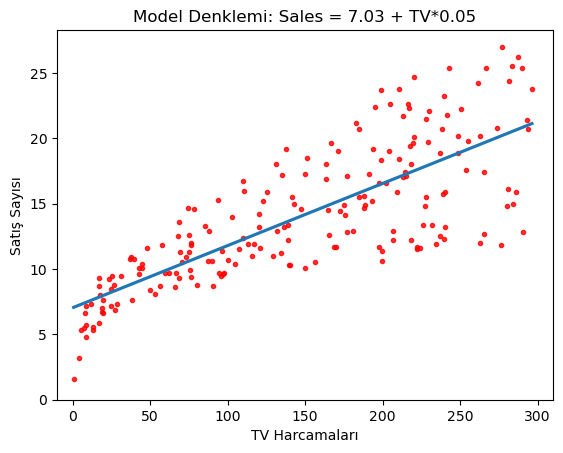

In [31]:
import matplotlib.pyplot as plt

g = sns.regplot(x=df["TV"], y=df["sales"], ci=None, scatter_kws={'color':'r', 's':9})
g.set_title("Model Denklemi: Sales = 7.03 + TV*0.05")
g.set_ylabel("Satış Sayısı")
g.set_xlabel("TV Harcamaları")
plt.xlim(-10,310)
plt.ylim(bottom=0);

# kurmuş olduğumuz linear regresyon modelinin grafik hali de bu şekilde

## scikit-learn


makina öğrenmesi algoritmalarını barındıran güzel bir python framework'üdür.

In [34]:
# şimdi buradan da model kurmayı bir görelim:

In [35]:
from sklearn.linear_model import LinearRegression

X = df[["TV"]]
y = df["sales"]
reg = LinearRegression()
model = reg.fit(X, y)

In [36]:
model.intercept_

7.032593549127693

In [37]:
model.coef_

array([0.04753664])

## Tahmin

Bu kurmuş olduğumuz **Sales = 7.03 + TV*0.05** modeliyle bir kaç farklı tahmin gerçekleştireceğiz. Örneğin 30 birim tv reklam harcaması olduğunda satışlar ne olur?

In [40]:
# manuel hesaplama:

In [41]:
manuel_bir_sekilde_yukaridaki_degeri_böyle_hesaplayabiliriz =  7.03 + 30 * 0.05

sonucu_goster = manuel_bir_sekilde_yukaridaki_degeri_böyle_hesaplayabiliriz

sonucu_goster # 8.53 olacakmış

8.530000000000001

In [42]:
# model ile hesaplama:

In [43]:
X = df[["TV"]]
y = df["sales"]
reg = LinearRegression()
model = reg.fit(X, y)

model.predict([[30]]) # görüldüğü üzere böyle de yapabiliriz yukarıdaki manuel işlemi

C:\Users\since\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([8.45869276])

In [44]:
# eğer bize satış ekibi derse ki şu şu şu değerlerin hepsi için tahminleri görmek istiyoruz diye. böyle bir array verebiliriz içerisine predictin

degerler = [[30],[55],[102],[1111]]
model.predict(degerler)

C:\Users\since\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([ 8.45869276,  9.64710877, 11.88133087, 59.84580107])

## Artıklar ve makina öğrenmesindeki önemi

Artık değerlerden kastımız, gerçek değerler ile modelin tahmin ettiği değerler arasındaki farktır.

In [47]:
from sklearn.metrics import mean_squared_error, r2_score

In [48]:
lm = smf.ols("sales ~ TV", df)
model = lm.fit()

In [49]:
mse = mean_squared_error(y, model.fittedvalues) # tahmin edilen değerlerle gerçek değerler arasındaki karelerin ortalaması

In [50]:
mse # birim başına yapacağımız ortalama hata yani mse

10.512652915656757

In [51]:
rmse = np.sqrt(mse) # mse değerimizin kareköklü hali

In [52]:
rmse

3.2423221486546887

In [53]:
reg.predict(X)[:10] # yukarıda tanımladığımız linear regression modelinin tahmin edilen değerleri

array([17.97077451,  9.14797405,  7.85022376, 14.23439457, 15.62721814,
        7.44616232,  9.76595037, 12.74649773,  7.44140866, 16.53041431])

In [54]:
y[:10] # gerçek değerler bunlar da

0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
5     7.2
6    11.8
7    13.2
8     4.8
9    10.6
Name: sales, dtype: float64

In [55]:
k_t = pd.DataFrame({"y_gercek":y[0:10], "y_tahmin":reg.predict(X)[:10]})

In [56]:
k_t["hata"] = (k_t["y_gercek"]-k_t["y_tahmin"]).abs()
k_t # buradaki hata sütunumuz aslında artık değerlerimiz olmuş oldu.

,y_gercek,y_tahmin,hata
0,22.1,17.970775,4.129225
1,10.4,9.147974,1.252026
2,9.3,7.850224,1.449776
3,18.5,14.234395,4.265605
4,12.9,15.627218,2.727218
5,7.2,7.446162,0.246162
6,11.8,9.765950,2.034050
7,13.2,12.746498,0.453502
8,4.8,7.441409,2.641409
9,10.6,16.530414,5.930414


In [57]:
k_t["hata"].median() # gerçek değerlerimizle tahmin edilen değerlerimizin ortalama hatası

2.337729141412667

Bir model kurduktan sonra az önce bizim aldığımız gibi artıklarımız(hatalarımız) olur. Normalde bunların da üzerine model kurar, sonra yine ortaya çıkan hatalar üzerinden de yine model kurarız. Bunlar editive modellerdir. Hatalar üzerinde modeller serisi oluşturularak hataların optimize edilmesi sağlanır. Yani her zaman amacımız bu ortaya çıkan hata sütunundaki değerleri azaltmak, optimize etmektir. Yukarıda median ile ortalamayı aldım, çünkü bu daha anlamlı olacaktır hatayı anlatmak için. buradan sonra bir grafik çizdirilip hatanın dağılımına bakılıp hata en çok verisetinin nerelerinde yoğunlaşmış diye bakılmalı. örneğin verisetinin %95'inde hata çok az ama kalan %5'inde çok fazla, bu kalan %5lik kısmın verisetinde nereye denk geldiğine bakılıp buradaki verilerde yapısal bir hata var mı yok mu diye bakılmalı, incelenmeli, analiz edilmeli.

In [59]:
model.resid[:10] 
# yukarıda yaptığımız onca işlem aslında burada yapılıyor. bu verileri bir k_t verisetindeki hata sütununda incelersek aynısı olduğunu görürüz. 
# yani bu bize modelin hatalarını/artıklarını verir

0    4.129225
1    1.252026
2    1.449776
3    4.265605
4   -2.727218
5   -0.246162
6    2.034050
7    0.453502
8   -2.641409
9   -5.930414
dtype: float64

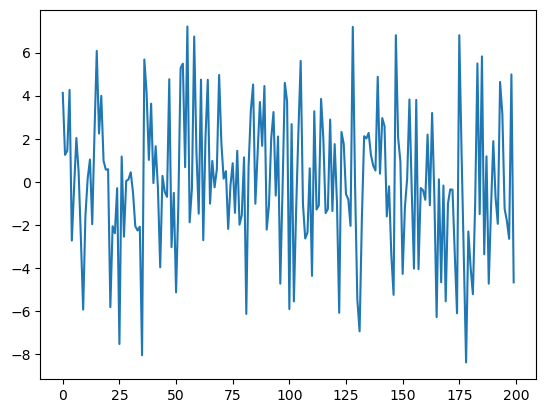

In [60]:
plt.plot(model.resid) # burada hataların dağılımını görebiliriz. bu veriseti için dağılım normaldir diyebiliriz.

# Çoklu Doğrusal Regresyon

Temel amaç, bağımlı ve bağımsız değişkenler arasındaki ilişkiyi ifade eden doğrusal fonksiyonları bulmaktır.

1) Bağımlı değişkeni etkileyen bağımlı değişkenleri bulmak
2) Bağımlı değişkeni etkileyen bağımsız değişkenleri bulmak

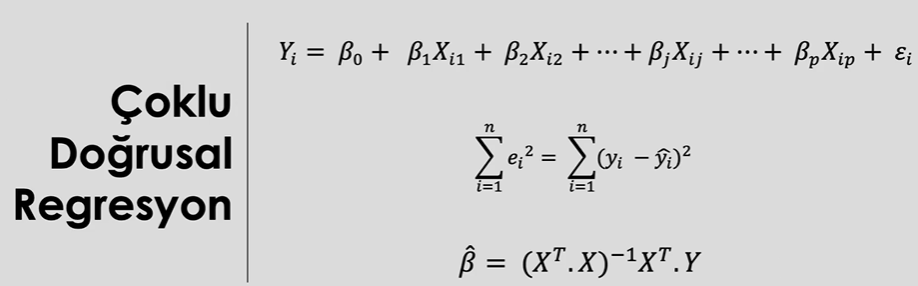

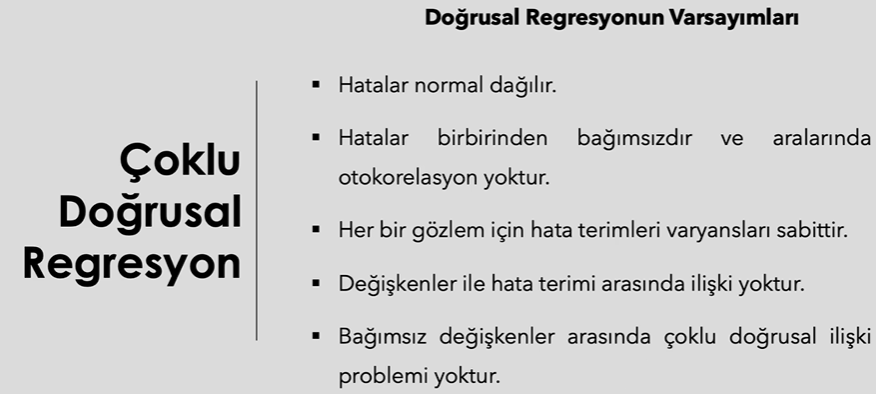

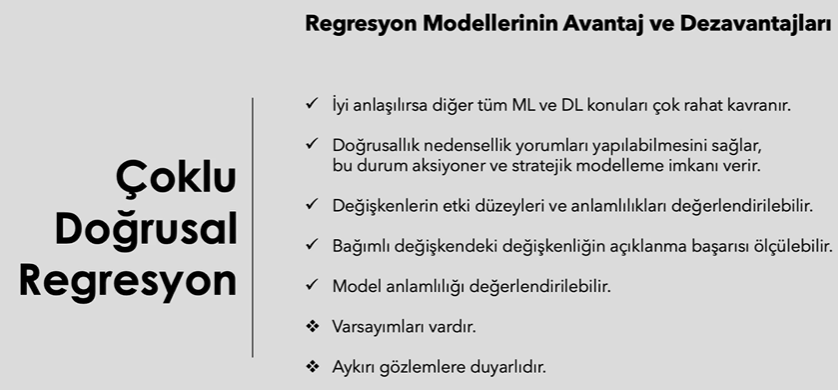

### Şimdi uygulama kısmına gelelim

In [64]:
import pandas as pd

ad = pd.read_csv("Advertising.csv", usecols=[1,2,3,4])

df = ad.copy()

df

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


In [65]:
X = df.drop("sales", axis=1) # bağımsız değişkenleri daha net inceleyebilmek için korelasyon bulunulan sales'i çıkarttığımız X dataframe'i

X[0:10]

,TV,radio,newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4
5,8.7,48.9,75.0
6,57.5,32.8,23.5
7,120.2,19.6,11.6
8,8.6,2.1,1.0
9,199.8,2.6,21.2


In [66]:
y = df["sales"]
y

0      22.1
1      10.4
2       9.3
3      18.5
4      12.9
       ... 
195     7.6
196     9.7
197    12.8
198    25.5
199    13.4
Name: sales, Length: 200, dtype: float64

In [67]:
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
# train ve test verisetinin ayrımı, skoru hesaplamak ve tahmin işi içi 3 adet fonksiyonlar aldık

In [68]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# burada verilerin %20'si test verisi olsun, dolayısıyla %80'i train veriseti olsun demiş olduk ve X ve y verisetlerini verdik

In [69]:
X_train.shape

(160, 3)

In [70]:
X_test.shape

(40, 3)

In [71]:
y_train.shape

(160,)

In [72]:
y_test.shape

(40,)

In [73]:
df.shape # verisetimizin ilk hali böyleydi. 160'a 40 olarak, 80'e 20 şeklinde train ve test olarak ayırmış

(200, 4)

### Çoklu doğrusal regresyon modelinin kurulmasını 2 şekilde gerçekleştirebiliriz.
1) statsmodels (yorumlanma ihtiyacı vs varsa)
2) scikit-learn

### Statsmodels ile

In [76]:
lm = sm.OLS(y_train, X_train)

In [77]:
model = lm.fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                  sales   R-squared (uncentered):                   0.982
Model:                            OLS   Adj. R-squared (uncentered):              0.982
Method:                 Least Squares   F-statistic:                              2935.
Date:                Sun, 13 Jul 2025   Prob (F-statistic):                   1.28e-137
Time:                        18:12:04   Log-Likelihood:                         -336.65
No. Observations:                 160   AIC:                                      679.3
Df Residuals:                     157   BIC:                                      688.5
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
TV             0.0531      0.001     36.467      0.000       0.050       0.056
radio          0.2188      0.011     20.138      0.000       0.197       0.240
newspaper      0.0239      0.008      3.011      0.003       0.008       0.040
==============================================================================
Omnibus:                       11.405   Durbin-Watson:                   1.895
Prob(Omnibus):                  0.003   Jarque-Bera (JB):               15.574
Skew:                          -0.432   Prob(JB):                     0.000415
Kurtosis:                       4.261   Cond. No.                         13.5
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Scikit-learn ile

In [79]:
lm = LinearRegression()
model = lm.fit(X_train, y_train)

In [80]:
model.intercept_ # sabit katsayımız olan b0 katsayısı bu şekilde

2.979067338122629

In [81]:
model.coef_ # TV, radio, newspaper katsayıları bu şekilde

array([0.04472952, 0.18919505, 0.00276111])

## Tahmin

az önceki değerlerden anladığımız kadarıyla model denklemi şöyle:

model denklemi: 

sales = 0.044 * TV + 0.189 * radio + 0.0027 * newspaper

soru: örneğin 30 birim tv, 10 birim radio, 40 birim newspaper reklam harcamaları yapıldığında satışların tahmini değeri ne olur?

In [84]:
yeni_tahmin = [[30],[10],[40]]
yeni_tahmin = pd.DataFrame(yeni_tahmin).T

In [85]:
model.predict(yeni_tahmin) # görebileceğimiz üzere 30 birim tv, 10 birim radio, 40 birim newspaper harcaması yapıldığında satış 6.32334798 olacakmış

C:\Users\since\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([6.32334798])

In [86]:
rmse_train = np.sqrt(mean_squared_error(y_train, model.predict(X_train))) # eğitim hatamız
rmse_train

1.644727765644337

In [87]:
rmse_test = np.sqrt(mean_squared_error(y_test, model.predict(X_test))) # test hatamız
rmse_test

1.7815996615334502

In [88]:
# yani yeni tahminimiz 6.32334798 idi, buna +- 1.644727765644337 değerini koyduğumuzda, 30 birim tv, 10 birim radio, 40 birim newspaper harcaması yapıldığında 
# satışın çıkabileceği aralığı söylemiş oluruz. yani 
# 30 birim tv, 10 birim radio, 40 birim newspaper harcaması yapıldığında satış;
# 4.67862021436 < satış < 7.97007574564 aralığında olacak % 95 ihtimalle falan gibi bir ifade kullanabiliriz

## Model Tuning / Model Doğrulama

Çoklu doğrusal regresyonda dışsal parametre olmadığı için burada model tuning işlemini model doğrulama olarak ele alacağız

In [91]:
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [92]:
X = df.drop('sales', axis=1)
y = df["sales"]
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.20,
                                                    random_state=42)

lm = LinearRegression()
model = lm.fit(X_train, y_train)

In [93]:
np.sqrt(mean_squared_error(y_train, model.predict(X_train)))

1.644727765644337

In [94]:
model.score(X_train, y_train)

0.8957008271017818

In [95]:
# yukarıdaki kodda random_state=42 kullandık. bu, eğitim ve test setlerini aynı kümelere böl demek. bunu yaptığımızda aldığımız sonuçlar sabit olur
# çünkü aynı kümeler üzerinde çalışıyor oluruz. bu değeri değiştirdikçe hata kareler ve modelin başarısının da ve diğer parametrelerin de
# değiştiğini görüyor olucaz. bu problemi giderebilmek adına cross-validation yöntemi kullanılır.

In [96]:
cross_val_score(model, X_train, y_train, cv=10, scoring="r2") # 10 katmanlı, r2 skorlama metodunu kullana cross-validation yöntemi

array([-0.10975169,  0.87992761,  0.88460907,  0.95616404,  0.93017934,
        0.92369938,  0.86467693,  0.95081368,  0.7622523 ,  0.87097792])

In [97]:
model.score(X_train, y_train) # yani doğru değer bu değil, aşağıdaki

0.8957008271017818

In [98]:
cross_val_score(model, X_train, y_train, cv=10, scoring="r2").mean() # bu şekilde valide edilmiş, daha güvenilir model r2 değeri budur

0.791354859691634

In [99]:
np.sqrt(-cross_val_score(model, 
                X_train, 
                y_train, 
                cv=10, 
                scoring="neg_mean_squared_error")) # burada rmse(hata kareler)'in cross valide edilmiş daha doğru hallerini görüyoruz

array([2.36072749, 1.69185011, 1.43702708, 1.04492575, 1.28902985,
       1.58333206, 1.71120332, 1.41847523, 2.68793677, 1.28901607])

In [100]:
np.sqrt(mean_squared_error(y_train, model.predict(X_train))) # yani hata kareler bu değil, aşağıdaki

1.644727765644337

In [101]:
np.sqrt(-cross_val_score(model, 
                X_train, 
                y_train, 
                cv=10, 
                scoring="neg_mean_squared_error")).mean()

1.6513523730313335

# PCR - Temel Bileşen Regresyonu

Değişkenlere boyut indirgeme uygulandıktan sonra çıkan bileşenlere regresyon modeli kurulması fikrine dayanır .

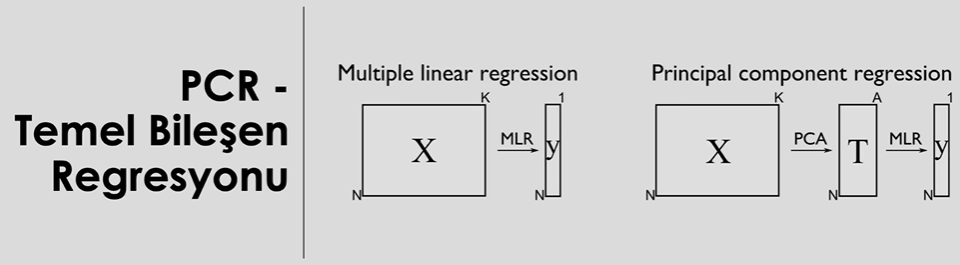

Çoklu regresyonda bildiğimiz gibi bağımsız değişkenler üzerinden bir model kurulup y tahminleri elde ediliyordu. Sağ tarafta görüleceği üzere, temel bişen regresyonunda ise bağımsız değişkenlere boyut indirgeme uygulanır(T olur) ve ortaya çıkan bileşenlere regresyon modeli kurulup y tahmin elde edilir.

Gerçek hayatta verilerimizde genelde bağımsız değişkenlerin birbirleriyle olan korelasyonu yüksek olur. Bu da benzer tahminsel bilgileri barındırdıkları anlamına geliyor. Bağımsız değişkenler arası yüksek korelasyona sahip olunması, regresyon bölümünde bahsettiğimiz çoklu doğrusal bağlantı problemini ortaya çıkartıyor. Bu problem olduğunda ise, en küçük kareler yöntemiyle elde edilen ekk tahmincileri/katsayılarının varyansını artırmakta ve yanlılık yaratmaktadır çoklu doğrusal bağlantı problemi. Benzer şekide gerçek hayatta sütun sayısının satır sayısından çok olduğu örnekler de olabiliyor, bu durum da "çok boyutluluk laneti" olarak adlandırılıyor. Her iki durumda da ekk tahmincileri yanlılık ortaya çıkartmış oluyor. bu duruma çözüm olarak temel bişen regresyonu geliştirilmiştir. Bu işlem de şöyle yapılıyor, örneğin 100 sütunlu bir veriseti var, ben bu 100 sütunu indirgemek istediğimde, bunu 5 sütuna indirgerim ve bazı verikayıplarını da göze alarak bu işlemi yaparım ve indirgeme işlemi yapmış olurum. yani 100 sütunun temsil ettiği bilgi, 5 sütunla temsil edilmeye çalışılır. Ortaya çıkan bu 5 sütunlu verisetine de regresyon modeli uygulanınca, indirgenmiş olan bu verisetine uygulanan regresyon modeli de PCR-Temel bileşen regresyonu diye adlandırılır.

## PCR Model

In [105]:
hit = pd.read_csv("Hitters.csv") # bazı basketbolcuların özelliklerini veren veriseti

df = hit.copy()

In [106]:
df = df.dropna()

df

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N
5,594,169,4,74,51,35,11,4408,1133,19,501,336,194,A,W,282,421,25,750.0,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,497,127,7,65,48,37,5,2703,806,32,379,311,138,N,E,325,9,3,700.0,N
318,492,136,5,76,50,94,12,5511,1511,39,897,451,875,A,E,313,381,20,875.0,A
319,475,126,3,61,43,52,6,1700,433,7,217,93,146,A,W,37,113,7,385.0,A
320,573,144,9,85,60,78,8,3198,857,97,470,420,332,A,E,1314,131,12,960.0,A


In [107]:
y = df["Salary"] # bağımlı değişkenimizi kaydetmiş olduk

In [108]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
AtBat,263.0,403.642586,147.307209,19.0,282.5,413.0,526.0,687.0
Hits,263.0,107.828897,45.125326,1.0,71.5,103.0,141.5,238.0
HmRun,263.0,11.619772,8.757108,0.0,5.0,9.0,18.0,40.0
Runs,263.0,54.745247,25.539816,0.0,33.5,52.0,73.0,130.0
RBI,263.0,51.486692,25.882714,0.0,30.0,47.0,71.0,121.0
Walks,263.0,41.114068,21.718056,0.0,23.0,37.0,57.0,105.0
Years,263.0,7.311787,4.793616,1.0,4.0,6.0,10.0,24.0
CAtBat,263.0,2657.543726,2286.582929,19.0,842.5,1931.0,3890.5,14053.0
CHits,263.0,722.186312,648.199644,4.0,212.0,516.0,1054.0,4256.0
CHmRun,263.0,69.239544,82.197581,0.0,15.0,40.0,92.5,548.0


In [109]:
dms = pd.get_dummies(df[['League', 'Division', 'NewLeague']]) # kategorik değişkenleri sürekli değişkenlere çevirdik ama dummy değişken tuzağı oluştu
dms.head()

,League_A,League_N,Division_E,Division_W,NewLeague_A,NewLeague_N
1,False,True,False,True,False,True
2,True,False,False,True,True,False
3,False,True,True,False,False,True
4,False,True,True,False,False,True
5,True,False,False,True,True,False


In [110]:
X_ = df.drop(["Salary","League","Division","NewLeague"],axis=1).astype("float")

# yeni bir dataframe oluşturduk ve içerisinde bağımlı değişken olan Salary ve kategorik değişkenleri çıkartmış olduk ve kalan tüm verileri float yaptık

In [111]:
X_.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors
1,315.0,81.0,7.0,24.0,38.0,39.0,14.0,3449.0,835.0,69.0,321.0,414.0,375.0,632.0,43.0,10.0
2,479.0,130.0,18.0,66.0,72.0,76.0,3.0,1624.0,457.0,63.0,224.0,266.0,263.0,880.0,82.0,14.0
3,496.0,141.0,20.0,65.0,78.0,37.0,11.0,5628.0,1575.0,225.0,828.0,838.0,354.0,200.0,11.0,3.0
4,321.0,87.0,10.0,39.0,42.0,30.0,2.0,396.0,101.0,12.0,48.0,46.0,33.0,805.0,40.0,4.0
5,594.0,169.0,4.0,74.0,51.0,35.0,11.0,4408.0,1133.0,19.0,501.0,336.0,194.0,282.0,421.0,25.0


In [112]:
X = pd.concat([X_, dms[["League_N", "Division_W", "NewLeague_N"]]],axis=1)
X

# burada dummy değişken tuzağından arındırılmış şekilde X_ ve dms dataframelerini concat ile birleştirdik

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,League_N,Division_W,NewLeague_N
1,315.0,81.0,7.0,24.0,38.0,39.0,14.0,3449.0,835.0,69.0,321.0,414.0,375.0,632.0,43.0,10.0,True,True,True
2,479.0,130.0,18.0,66.0,72.0,76.0,3.0,1624.0,457.0,63.0,224.0,266.0,263.0,880.0,82.0,14.0,False,True,False
3,496.0,141.0,20.0,65.0,78.0,37.0,11.0,5628.0,1575.0,225.0,828.0,838.0,354.0,200.0,11.0,3.0,True,False,True
4,321.0,87.0,10.0,39.0,42.0,30.0,2.0,396.0,101.0,12.0,48.0,46.0,33.0,805.0,40.0,4.0,True,False,True
5,594.0,169.0,4.0,74.0,51.0,35.0,11.0,4408.0,1133.0,19.0,501.0,336.0,194.0,282.0,421.0,25.0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,497.0,127.0,7.0,65.0,48.0,37.0,5.0,2703.0,806.0,32.0,379.0,311.0,138.0,325.0,9.0,3.0,True,False,True
318,492.0,136.0,5.0,76.0,50.0,94.0,12.0,5511.0,1511.0,39.0,897.0,451.0,875.0,313.0,381.0,20.0,False,False,False
319,475.0,126.0,3.0,61.0,43.0,52.0,6.0,1700.0,433.0,7.0,217.0,93.0,146.0,37.0,113.0,7.0,False,True,False
320,573.0,144.0,9.0,85.0,60.0,78.0,8.0,3198.0,857.0,97.0,470.0,420.0,332.0,1314.0,131.0,12.0,False,False,False


In [113]:


print("X_train", X_train.shape)
print("y_train", y_train.shape)
print("X_test", X_test.shape)
print("y_test", y_test.shape)

training = df.copy()
print("training", training.shape)


X_train (160, 3)
y_train (160,)
X_test (40, 3)
y_test (40,)
training (263, 20)


In [114]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale
pca = PCA()

In [115]:
X_reduced_train = pca.fit_transform(scale(X_train))

# şu anda elimizde değişken saıysı kadar bileşen oluşturulmuş fakat aralarındaki bağlantı problemi ortadan kalkmış, indirgenmiş bir veriseti var.
# burada pca.fit() diye de yapabilirdik ancak o durumda, model nesnesi oluşur. Biz fit_transform ile oluşturduk ki hem x'e göre model oluşturulacak
# hem de boyut indirgeme işlemi yapılacak. sadece transform fonksiyonu ise x boyut indirgeme işlemini yapar. bu fonksiyonla iki işi birden yapıyoruz
# pca'ın açıklamasında da söylediğimiz şeyi yaptık: var olan sütunları daha az sütun ile açıkladık
# bileşen: Orijinal sütunların yeni kombinasyonlarıdır. PCA ile veriyi daha az boyutta ve bilgi kaybı olmadan temsil ederiz.

In [116]:
X_reduced_train[0:1,:] # burada birinci gözlem ve tüm bileşenleri görüyoruz şu anda

array([[-1.01213209,  0.30567565, -0.4656865 ]])

In [117]:
np.cumsum(np.round(pca.explained_variance_ratio_, decimals=4)*100)  # kümülatif olarak açıklanan varyansı görüyoruz

# daha az sütuna indirgedik ama önceki sütunda bulunan bilgileri yeni ve indirgenmiş sütun kombinasyonunda ne kadar temsil ediyoruzu gösteriyor. 
# birinci sütunu %33.03, bir ve ikinci sütunu 52.97, bir, iki ve üçüncüyü 69.04, bir, iki, üç ve dördüncüyü 78.16 ......
# en başa dönüp bakarsak eğer, başlangıçta 20 sütunlu bir veriseti olduğunu görebiliriz. 
# burada ise 10.sütuna gelinince verisetinin %96.27'sini açıklar hale gelmişiz. yani pca'ın amacı olan daha az sütuna indirgeme işlemini yapmışız

array([ 46.49,  79.65, 100.  ])

In [118]:
# şimdi bunu modele verelim:

lm = LinearRegression()
pcr_model = lm.fit(X_reduced_train, y_train)

In [119]:
pcr_model.intercept_

14.1

In [120]:
pcr_model.coef_

array([ 2.49349496, -3.58624493,  1.7001802 ])

## Eğittimiz PCR model ile Tahmin

In [122]:
y_pred = pcr_model.predict(X_reduced_train)

In [123]:
y_pred[0:10]

array([ 9.68827502, 12.67337707, 10.0553326 ,  8.20010235, 13.49562077,
        5.42585998,  9.2767456 , 14.14222434,  8.83116901, 11.63897134])

In [124]:
np.sqrt(mean_squared_error(y_train, y_pred)) # hata farkı. bence çok fazla. iyi bir modelimiz yok

1.644727765644337

In [125]:
df["Salary"].median()

425.0

In [126]:
r2_score(y_train, y_pred) 

0.8957008271017818

## Model Tuning

PCR'da model tuning öneme sahiptir çünkü bileşen sayısı vb parametreleri düzenleyerek elde edilen modelin doğruluğu iyileştirilebilir

In [129]:
lm = LinearRegression()

X_reduced_test = pca.fit_transform(scale(X_test))
pcr_model = lm.fit(X_reduced_train, y_train)

y_pred = pcr_model.predict(X_reduced_test)

np.sqrt(mean_squared_error(y_test, y_pred)) # modelin test hatası

2.8081668910156723

In [130]:
# şimdi bu test hatasını bileşen sayısıyla oynayarak düzenlemeye çalışacağız. bileşen sayısı arttıkça ne oluyor, azaldıkça ne oluyor diye bakacağız

pcr_model = lm.fit(X_reduced_train[:,0:1], y_train)

y_pred = pcr_model.predict(X_reduced_test[:,0:1])

np.sqrt(mean_squared_error(y_test, y_pred)) # 1 bileşenle tahmin ettirilen modelin test hatası

# görülebileceği üzere tüm bileşenlerle yapınca çıkan hatadan daha az hata çıktı 1 bileşenle tahmin yapınca 

4.07211989412659

In [131]:
pcr_model = lm.fit(X_reduced_train[:,0:3], y_train)

y_pred = pcr_model.predict(X_reduced_test[:,0:3])

np.sqrt(mean_squared_error(y_test, y_pred)) # 3 bileşenle tahmin ettirilen modelin test hatası

# daha da az çıktı hata.

2.8081668910156723

In [132]:
pcr_model = lm.fit(X_reduced_train[:,0:10], y_train)

y_pred = pcr_model.predict(X_reduced_test[:,0:10])

np.sqrt(mean_squared_error(y_test, y_pred)) # 10 bileşenle tahmin ettirilen modelin test hatası

# daha da az çıktı hata.

2.8081668910156723

In [133]:
pcr_model = lm.fit(X_reduced_train[:,0:12], y_train)

y_pred = pcr_model.predict(X_reduced_test[:,0:12])

np.sqrt(mean_squared_error(y_test, y_pred)) # 12 bileşenle tahmin ettirilen modelin test hatası

# daha da fazla çıktı, o yüzden 10'da kalsın. en optimum seçenek oymuş. bu şekilde cross-validation ile deneyeceğiz ve en iyi bileşen sayısı versiyonu
# bulunca orada bırakacağız

2.8081668910156723

Text(0.5, 1.0, 'Maaş Tahmin Modeli İçin PCR Model Tuning')

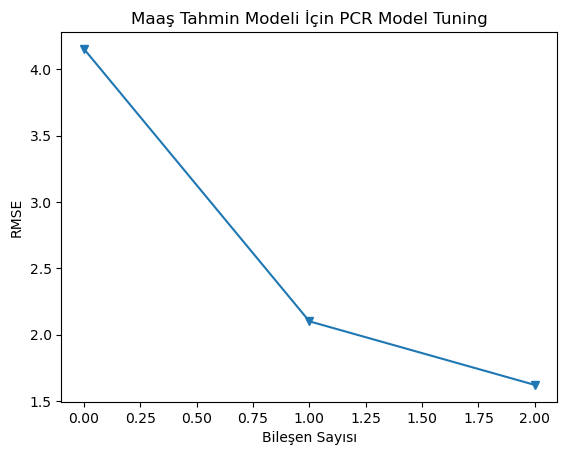

In [134]:
# yukarıdaki işlemi amele gibi tek tek yapmak yerine bu şekilde otomatitze edebiliriz
from sklearn import model_selection

cv_10 = model_selection.KFold(n_splits = 10,
                              shuffle = True,
                              random_state = 1)

lm = LinearRegression()

RMSE = []

for i in np.arange(1, X_reduced_train.shape[1] + 1):
    score = np.sqrt(-1 * model_selection.cross_val_score(
        lm,
        X_reduced_train[:, :i],
        y_train.ravel(),
        cv=cv_10,
        scoring='neg_mean_squared_error'
    )).mean()
    RMSE.append(score)

plt.plot(RMSE, '-v')
plt.xlabel('Bileşen Sayısı')
plt.ylabel('RMSE')
plt.title('Maaş Tahmin Modeli İçin PCR Model Tuning')

# burada yapılan şey aslında tek tek bileşen sayısını yazıp error'a bakıp hee en azı buymuş, o zaman bunu kullanayım demek yerine,
# tüm errorları tek grafikte gördüğümüz ve tekte en düşük error'u seçebilmemize imkan tanır
# bu grafikten anladığımız şey, aslında en optimum bileşen sayısı 10 değil, 6'ymış. onu seçersek hata en aza inecek. ayrıyeten bunu train veriseti
# üzerinde yaparız. bunu da unutma, test değil başka bir şey değil. Train veriseti.

In [135]:
pcr_model = lm.fit(X_reduced_train[:,0:6], y_train)

y_pred = pcr_model.predict(X_reduced_train[:,0:6])

np.sqrt(mean_squared_error(y_train, y_pred)) # 6 bileşenle tahmin ettirilen modelin test hatası

# TRAIN versetleri üzerindeki en optimum bileşen sayısının 6 olduğunu grafikten anladık ve buna göre tahminimizi yaptık.

1.644727765644337

In [136]:
pcr_model = lm.fit(X_reduced_train[:,0:6], y_train)

y_pred = pcr_model.predict(X_reduced_test[:,0:6])

np.sqrt(mean_squared_error(y_test, y_pred)) # 6 bileşenle tahmin ettirilen modelin test hatası

# bu da test veriseti üzerindeki sonuç

2.8081668910156723

In [137]:
# örnek veriseti üzerinden pca'de nasıl bileşenler seçilir, seçilince ne olur? nasıl olur vs gibi soruların cevabı. bakarsın buna

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Örnek veriset (senin verdiğin format)
data = {
    'AtBat': [315, 479, 496, 321, 594, 185, 298, 323, 401, 574],
    'Hits': [81, 130, 141, 87, 169, 37, 73, 81, 92, 159],
    'HmRun': [7, 18, 20, 10, 4, 1, 8, 6, 17, 21],
    'Runs': [24, 66, 65, 39, 74, 23, 24, 26, 49, 107],
    'RBI': [38, 72, 78, 42, 51, 8, 38, 32, 66, 75],
    'Walks': [39, 76, 37, 30, 35, 21, 24, 8, 65, 59],
    'Years': [14, 3, 11, 2, 11, 2, 15, 12, 5, 6],
    'CAtBat': [3449, 1624, 5628, 396, 4408, 214, 4631, 3928, 1157, 2648],
    'CHits': [835, 457, 1575, 101, 1133, 42, 1108, 1082, 309, 735],
    'CHmRun': [69, 63, 225, 12, 19, 1, 101, 103, 48, 114],
    'CRuns': [321, 224, 828, 48, 501, 30, 500, 488, 159, 435],
    'CRBI': [414, 266, 838, 46, 336, 9, 451, 446, 204, 421],
    'CWalks': [375, 263, 354, 33, 194, 24, 375, 252, 246, 375],
    'PutOuts': [632, 880, 200, 805, 282, 76, 821, 343, 237, 632],
    'Assists': [43, 82, 11, 40, 421, 127, 118, 176, 140, 43],
    'Errors': [10, 14, 3, 4, 25, 7, 10, 4, 8, 10]
}

df = pd.DataFrame(data)
print("Orijinal Veriset:")
print(df.head())
print(f"\nVeriset boyutu: {df.shape}")

# 1. ADIM: Veriyi standardize et
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

print("\n" + "="*50)
print("1. ADIM: VERİYİ STANDARDIZE ET")
print("="*50)
print("Standardize öncesi ortalamalar:")
print(df.mean().round(2))
print("\nStandardize sonrası ortalamalar (0'a yakın olmalı):")
print(pd.DataFrame(df_scaled, columns=df.columns).mean().round(2))

# 2. ADIM: PCA uygula
pca = PCA(n_components=3)
pca_result = pca.fit_transform(df_scaled)

print("\n" + "="*50)
print("2. ADIM: PCA SONUÇLARI")
print("="*50)

# Her bileşenin açıkladığı varyans
print("Her bileşenin açıkladığı varyans yüzdesi:")
for i, variance in enumerate(pca.explained_variance_ratio_):
    print(f"Bileşen {i+1}: {variance:.3f} ({variance*100:.1f}%)")

print(f"\nToplam açıklanan varyans: {pca.explained_variance_ratio_.sum():.3f} ({pca.explained_variance_ratio_.sum()*100:.1f}%)")

# 3. ADIM: Bileşenlerin katsayılarını analiz et
print("\n" + "="*50)
print("3. ADIM: BİLEŞENLERİN KATSAYILARI")
print("="*50)

# Bileşen katsayıları tablosu
components_df = pd.DataFrame(
    pca.components_.T,
    columns=['Bileşen1', 'Bileşen2', 'Bileşen3'],
    index=df.columns
)

print("Bileşen katsayıları:")
print(components_df.round(3))

# 4. ADIM: Her bileşeni yorumla
print("\n" + "="*50)
print("4. ADIM: BİLEŞENLERİ YORUMLA")
print("="*50)

for i in range(3):
    print(f"\n--- BİLEŞEN {i+1} ANALİZİ ---")
    print(f"Açıkladığı varyans: {pca.explained_variance_ratio_[i]*100:.1f}%")
    
    # En yüksek katsayılı değişkenleri bul
    component_weights = components_df[f'Bileşen{i+1}'].abs().sort_values(ascending=False)
    print(f"En etkili değişkenler (mutlak değer):")
    
    for j, (var, weight) in enumerate(component_weights.head(5).items()):
        original_weight = components_df.loc[var, f'Bileşen{i+1}']
        print(f"  {j+1}. {var}: {original_weight:.3f} (mutlak: {weight:.3f})")
    
    # Yorumlama
    if i == 0:
        print("  → Muhtemelen 'Genel Performans' veya 'Kariyer İstatistikleri'")
    elif i == 1:
        print("  → Muhtemelen 'Deneyim' veya 'Pozisyon Özelliği'")
    else:
        print("  → Muhtemelen 'Özel Yetenek' veya 'Savunma/Hücum Dengesi'")

# 5. ADIM: Gerçek dönüşüm sonuçları
print("\n" + "="*50)
print("5. ADIM: DÖNÜŞTÜRÜLMÜŞ VERİSET")
print("="*50)

pca_df = pd.DataFrame(pca_result, columns=['Bileşen1', 'Bileşen2', 'Bileşen3'])
print("İlk 5 oyuncunun PCA skorları:")
print(pca_df.head())

# 6. ADIM: Varyans açıklaması
print("\n" + "="*50)
print("6. ADIM: VARYANS AÇIKLAMASI")
print("="*50)

print("Varyans nasıl hesaplanır:")
print("1. Her değişkenin ne kadar 'dağılım' gösterdiğine bakar")
print("2. Değişkenlerin birbiriyle ne kadar ilişkili olduğuna bakar")
print("3. En çok bilgi içeren yönü bulur")

# Korelasyon matrisi örneği
print("\nÖrnek: Bazı değişkenler arasındaki korelasyon:")
corr_example = df[['Hits', 'Runs', 'RBI', 'Years', 'CHits']].corr()
print(corr_example.round(3))

print("\n" + "="*50)
print("SONUÇ VE YORUMLAMA")
print("="*50)

print("BİLEŞEN FORMÜLLERI:")
for i in range(3):
    print(f"\nBileşen{i+1} = ", end="")
    terms = []
    for var in df.columns:
        coef = components_df.loc[var, f'Bileşen{i+1}']
        if abs(coef) > 0.1:  # Sadece önemli katsayıları göster
            sign = "+" if coef > 0 else ""
            terms.append(f"{sign}{coef:.2f}×{var}")
    print(" ".join(terms[:6]) + "...")  # İlk 6 terimi göster

print(f"\nÖZET:")
print(f"• Orijinal veriset: {df.shape[1]} sütun")
print(f"• PCA sonrası: 3 sütun")
print(f"• Bilgi kaybı: {(1-pca.explained_variance_ratio_.sum())*100:.1f}%")
print(f"• En önemli bileşen: {pca.explained_variance_ratio_[0]*100:.1f}% varyans açıklıyor")

Orijinal Veriset:
   AtBat  Hits  HmRun  Runs  RBI  Walks  Years  CAtBat  CHits  CHmRun  CRuns  \
0    315    81      7    24   38     39     14    3449    835      69    321   
1    479   130     18    66   72     76      3    1624    457      63    224   
2    496   141     20    65   78     37     11    5628   1575     225    828   
3    321    87     10    39   42     30      2     396    101      12     48   
4    594   169      4    74   51     35     11    4408   1133      19    501   

   CRBI  CWalks  PutOuts  Assists  Errors  
0   414     375      632       43      10  
1   266     263      880       82      14  
2   838     354      200       11       3  
3    46      33      805       40       4  
4   336     194      282      421      25  

Veriset boyutu: (10, 16)

1. ADIM: VERİYİ STANDARDIZE ET
Standardize öncesi ortalamalar:
AtBat       398.6
Hits        105.0
HmRun        11.2
Runs         49.7
RBI          50.0
Walks        39.4
Years         8.1
CAtBat     2808.3
CHi

Kafa karışıklığı oldu biraz. her zamana model kurduktan sonra yapılacaklar sırasıyla şöyle:

1) İlkel yol ile train ve test hataları hesaplanır
2) elde edilen train ve test hatalarına cross validation yapılır
3) model tuning (modele en doğru parametreyi bulmak) : tuning(uygun hiperparametreyi bulmak) için cross validation yapılır.
4) en iyi parametreyi bulmak için train verisetini kullandık, artık onunla bir işimiz yok. şimdi final modeli kurulur
5) final modelin test hatasını hesapla. bu da tune edilmiş modelin değeri olur

# Kısmi En Küçük Kareler Regresyonu (PLS)

Değişkenlerin daha az sayıda ve çoklu doğrusal bağlantı problemi olmayan bileşenlere indirgenip regresyon modeli kurulması fikrine dayanır. Burada da aynı PCA'da olduğu gibi, p adet değişkenin p'den daha az sayıda değişken ile temsil ediliyor ve sonrasında modele veriliyor.

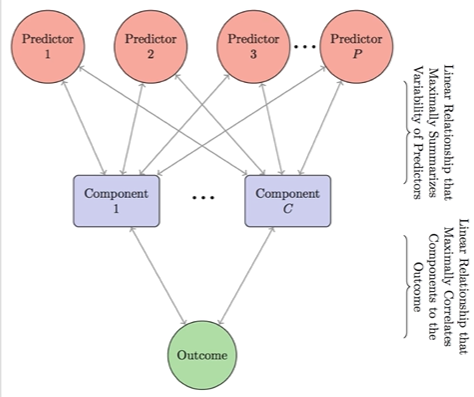

Predictor: Bağımsız değişkenler

Component(bileşenler): Bağımsız değişkenlerin indirgenmiş hali

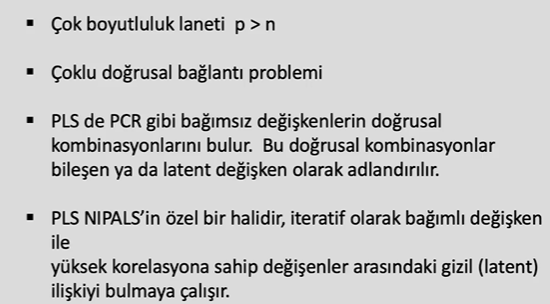

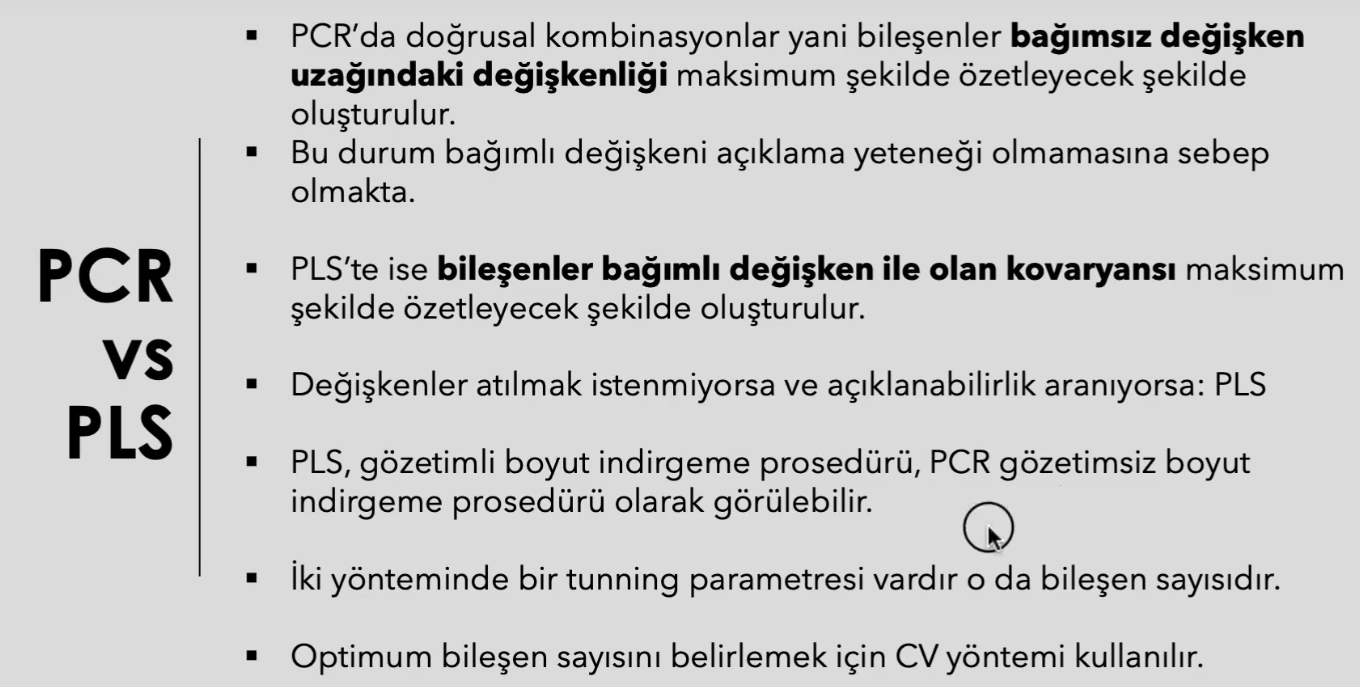

Yani PCR, bağımsız değişkenler kendi içerisinde, PLS'de ise, bağımlı değişken odaklı bir şekilde bu bileşenleri oluşturma işlemi yapılıyor

## PLS-Model

In [142]:
hit = pd.read_csv("Hitters.csv") # bazı basketbolcuların özelliklerini veren veriseti

df = hit.copy()

df = df.dropna()

dms = pd.get_dummies(df[['League', 'Division', 'NewLeague']])

y = df["Salary"] # bağımlı değişkenimizi kaydetmiş olduk

X_ = df.drop(["Salary","League","Division","NewLeague"],axis=1).astype("float")

X = pd.concat([X_, dms[["League_N", "Division_W", "NewLeague_N"]]],axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [143]:
from sklearn.cross_decomposition import PLSRegression, PLSSVD

In [144]:
# modelimizi kuruyoruz:

pls_model = PLSRegression().fit(X_train, y_train)

In [145]:
pls_model.coef_

C:\Users\since\anaconda3\Lib\site-packages\sklearn\cross_decomposition\_pls.py:503: FutureWarning: The attribute `coef_` will be transposed in version 1.3 to be consistent with other linear models in scikit-learn. Currently, `coef_` has a shape of (n_features, n_targets) and in the future it will have a shape of (n_targets, n_features).
  warnings.warn(


array([[ 35.32916493],
       [ 48.83425857],
       [ 18.50240933],
       [ 39.28117603],
       [ 30.59952998],
       [ 40.03398345],
       [ 16.85990516],
       [ 28.22289896],
       [ 32.73784993],
       [ 22.00875744],
       [ 33.60903032],
       [ 30.39402522],
       [ 25.73279799],
       [ 54.98835148],
       [  6.56590871],
       [ -0.90894359],
       [ 17.60903423],
       [-37.24246339],
       [ 14.69680385]])

In [146]:
pls_model = PLSRegression(n_components=6).fit(X_train, y_train) # bileşen sayısını 6 yapınca olan katsayılar:
pls_model.coef_

# görülebilecği üzere PCA'da ki gibi bileşn sayısını değiştirince çıkan sonuçların sayısı değişmiyor. PLS'in PCA'dan farkı bu.
# burada bağımlı değişkenle ilgilendiğimiz için sonuç değişmedi. sadece katsayıları değiştirir PLS

C:\Users\since\anaconda3\Lib\site-packages\sklearn\cross_decomposition\_pls.py:503: FutureWarning: The attribute `coef_` will be transposed in version 1.3 to be consistent with other linear models in scikit-learn. Currently, `coef_` has a shape of (n_features, n_targets) and in the future it will have a shape of (n_targets, n_features).
  warnings.warn(


array([[-108.74143193],
       [ 197.6386967 ],
       [  22.57338481],
       [  26.52768741],
       [ -25.67952167],
       [  54.16363009],
       [ -25.89997437],
       [   5.36637756],
       [  89.44665343],
       [  26.79039104],
       [ 102.43239418],
       [  68.82932424],
       [ -61.11470635],
       [  94.44121847],
       [  26.38215013],
       [ -45.01850138],
       [  77.17773908],
       [ -35.85447586],
       [ -45.66863853]])

## PLS Tahmin

In [148]:
pls_model = PLSRegression(n_components=2).fit(X_train, y_train)
pls_model

PLSRegression()

In [149]:
pls_model.predict(X_train)[:10] # X_train veriseti içerisindeki değerleri pls_model.coef_ katsayılarıyla işleme tabi tutup tahmin yapacak

array([[344.91941493],
       [848.87070769],
       [692.93622642],
       [185.56577984],
       [435.49196077],
       [987.49530026],
       [120.63097106],
       [289.9263406 ],
       [663.41886918],
       [817.90486641]])

In [150]:
y_pred = pls_model.predict(X_train) # train verisetindeki tahminleri gerçekleştiriyoruz

In [151]:
np.sqrt(mean_squared_error(y_train, y_pred)) # burada train error'a bakıyoruz

310.1167593109696

In [152]:
r2_score(y_train, y_pred) # r^2 değerimiz de bu şekilde

0.5140424486535482

In [153]:
y_pred = pls_model.predict(X_test) # test verisetindeki tahminleri gerçekleştiriyoruz

In [154]:
np.sqrt(mean_squared_error(y_test, y_pred)) 
# burada test error'a bakıyoruz. test hatası train hatasından yüksek çıktı. doğrusu da budur. aksi halde neden train ettik ki derdik

398.09956327448526

## Model Tuning

Text(0.5, 1.0, 'Salary')

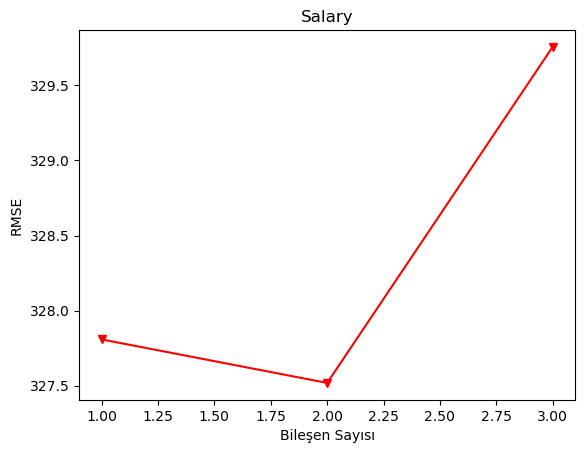

In [156]:
from sklearn import model_selection

cv_10 = model_selection.KFold(n_splits = 10,
                              shuffle = True,
                              random_state = 1)

RMSE = []

for i in np.arange(1, X_reduced_train.shape[1] + 1):
    pls = PLSRegression(n_components=i)
    score = np.sqrt(-1 * cross_val_score(
        pls,
        X_train,
        y_train,
        cv=cv_10,
        scoring='neg_mean_squared_error'
    )).mean()
    RMSE.append(score)

plt.plot(np.arange(1, X_reduced_train.shape[1]+1), RMSE, 'v-', c="r")
plt.xlabel('Bileşen Sayısı')
plt.ylabel('RMSE')
plt.title('Salary')

# burada gözlemleyebileceğimiz şey, hata kareler ortalamsının en az olduğu yeri tespit etmek. 
# ona göre de o noktanın bileşen sayısını kullanıp en az hatayı elde etmek
# örneğin buradan da anlayabileceğimiz üzere: en az hatayı 2 bileşende alacağız. bu sebeple 2 bileşenli olarak kullanacağız pls'mizi.

## Final Model

In [158]:
pls_model = PLSRegression(n_components=2).fit(X_train, y_train) # en az hata aldığımız 2 bileşen sayısı ile final model oluşturuyoruz

In [159]:
y_pred = pls_model.predict(X_test)

In [160]:
np.sqrt(mean_squared_error(y_test, y_pred)) # final model ile test hatamızı test ettik

398.09956327448526

# Ridge Regression

Amaç: Hata kareler toplamı RMSE'yi minimize eden katsayı, katsayılara ceza uygulayarak bulmaktır.

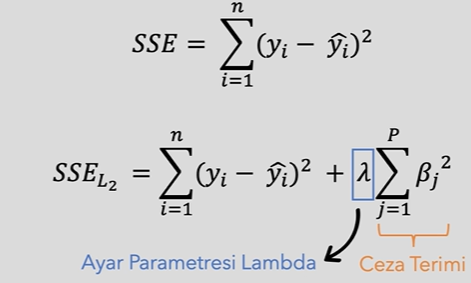

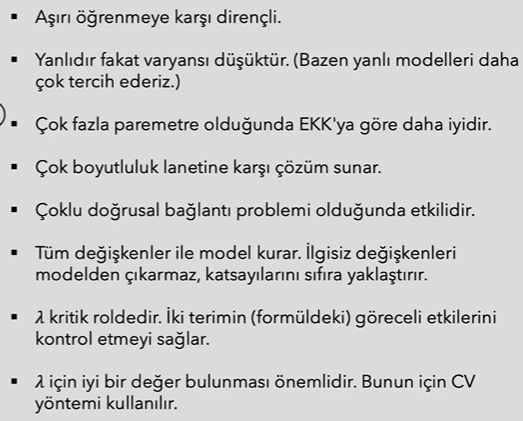

# Ridge Regression - Model

In [164]:
hit = pd.read_csv("Hitters.csv") # bazı basketbolcuların özelliklerini veren veriseti

df = hit.copy()

df = df.dropna()

dms = pd.get_dummies(df[['League', 'Division', 'NewLeague']])

y = df["Salary"] # bağımlı değişkenimizi kaydetmiş olduk

X_ = df.drop(["Salary","League","Division","NewLeague"],axis=1).astype("float")

X = pd.concat([X_, dms[["League_N", "Division_W", "NewLeague_N"]]],axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [165]:
from sklearn.linear_model import Ridge

In [166]:
ridge_model = Ridge(alpha=0.1).fit(X_train, y_train) # alpha = lambda olmuş oluyor. aslında cezalandıran arkadaş bu 

In [167]:
ridge_model

Ridge(alpha=0.1)

In [168]:
ridge_model.coef_

array([ -1.77435737,   8.80240528,   7.29595605,  -3.33257639,
        -2.08316481,   5.42531283,   7.58514945,  -0.13752764,
        -0.20779701,  -0.60361067,   1.7927957 ,   0.72866408,
        -0.68710375,   0.26153564,   0.26888652,  -0.52674278,
       112.14640272, -99.80997876, -48.07152768])

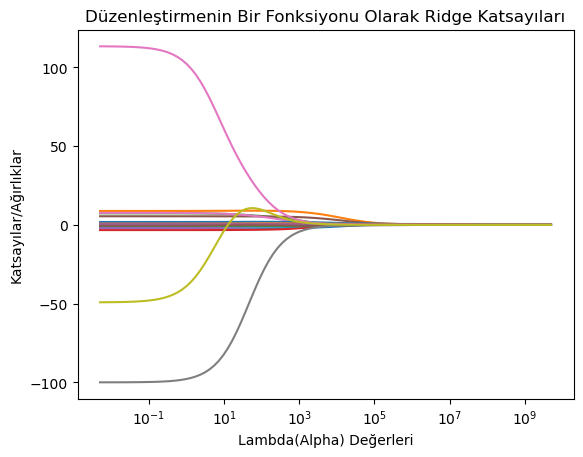

In [169]:
lambdalar = 10**np.linspace(10, -2, 100) * 0.5

ridge_model = Ridge()
katsayilar = []

for i in lambdalar:
    ridge_model.set_params(alpha=i)
    ridge_model.fit(X_train, y_train)
    katsayilar.append(ridge_model.coef_)

ax = plt.gca()
ax.plot(lambdalar, katsayilar)
ax.set_xscale('log')

plt.xlabel('Lambda(Alpha) Değerleri')
plt.ylabel('Katsayılar/Ağırlıklar')
plt.title('Düzenleştirmenin Bir Fonksiyonu Olarak Ridge Katsayıları');

# burada hangi alpha = ... değerinin bizim için optimum olduğunu bulma gayreti içerisindeyiz.
# alpha'yu bulmak şu demek: katsayılara uygulanan cezanın şiddetini bulmak
# optimum alpha değeri, tüm parametrelerin sıfıra yaklaşmadan hemen önceki aralıkta olduğunu söylemeliyiz.
# dolayısıyla, grafiğe bakarak optimum alpha değerinin 10^2 olabileceğini söyleyebiliriz.

In [170]:
ridge_model = Ridge(alpha=100).fit(X_train, y_train)

In [171]:
ridge_model.coef_

array([ -1.91364661,   8.95761888,   5.56011781,  -3.11736466,
        -1.3870488 ,   5.3154875 ,   5.10648962,  -0.1155687 ,
        -0.37230939,  -1.04807433,   1.9001643 ,   0.90078494,
        -0.64433817,   0.26965561,   0.2625772 ,  -0.30368762,
        19.39546773, -31.38777553,   9.55307828])

## Tahmin

In [173]:
y_pred = ridge_model.predict(X_test)

In [174]:
np.sqrt(mean_squared_error(y_test, y_pred))

357.8154668279846

## Model Tuning

In [176]:
# bu lambda değerlerinden hangisinin daha iyi olduğunu bu model tuning bölümünde Cross Validation ile belirleyeceğiz

lambdalar = 10**np.linspace(10, -2, 100) * 0.5

lambdalar[:5]

array([5.00000000e+09, 3.78231664e+09, 2.86118383e+09, 2.16438064e+09,
       1.63727458e+09])

In [177]:
from sklearn.linear_model import RidgeCV

In [178]:
# Önce veriyi ölçeklendir
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # Test verisi için de uygula

ridge_cv = RidgeCV(alphas=lambdalar, scoring="neg_mean_squared_error") # opitmum lambda değerini vermek için olan fonksiyonu kullanıyoruz. yukarıdaki bruth force yerine bunu kullandık
ridge_cv.fit(X_train_scaled, y_train)

# Eğer test setinde de tahmin yapmak istersek:
y_pred = ridge_cv.predict(X_test_scaled)

In [179]:
ridge_cv.alpha_

152.69277544167062

## Final model

In [181]:
ridge_tuned = Ridge(alpha=ridge_cv.alpha_).fit(X_train, y_train)

In [182]:
np.sqrt(mean_squared_error(y_test, ridge_tuned.predict(X_test)))

358.20814125715316

# Lasso Regresyon

Amaç: hata kareler toplamını minimize eden katsayıları, bu katsayılara ceza uygulayarak bulmaktır.

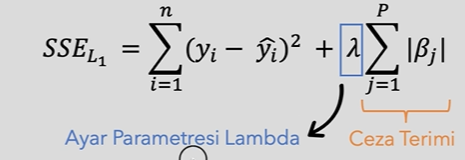

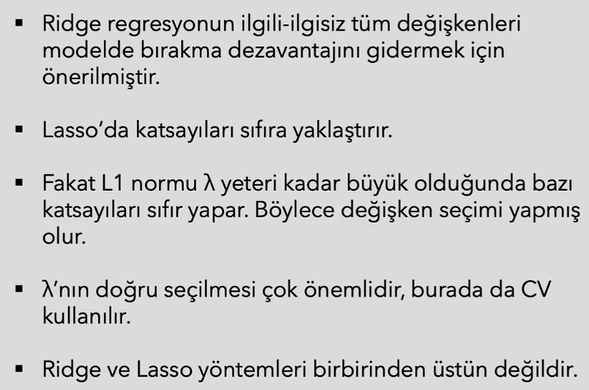

In [419]:
hit = pd.read_csv("Hitters.csv") # bazı basketbolcuların özelliklerini veren veriseti

df = hit.copy()

df = df.dropna()

dms = pd.get_dummies(df[['League', 'Division', 'NewLeague']])

y = df["Salary"] # bağımlı değişkenimizi kaydetmiş olduk

X_ = df.drop(["Salary","League","Division","NewLeague"],axis=1).astype("float")

X = pd.concat([X_, dms[["League_N", "Division_W", "NewLeague_N"]]],axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [421]:
from sklearn.linear_model import Lasso

In [488]:
lasso_model = Lasso(alpha=0.1).fit(X_train, y_train)

C:\Users\since\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.249e+06, tolerance: 3.899e+03
  model = cd_fast.enet_coordinate_descent(


In [490]:
lasso_model

Lasso(alpha=0.1)

In [492]:
lasso_model.coef_

array([-1.72206506e+00,  8.56210197e+00,  6.91175137e+00, -3.13240128e+00,
       -2.00771676e+00,  5.36159035e+00,  8.86871593e+00, -1.69520371e-01,
       -5.58121413e-02, -3.53962588e-01,  1.70961000e+00,  6.40603469e-01,
       -6.58519895e-01,  2.60093222e-01,  2.78717030e-01, -5.92690965e-01,
        1.12659630e+02, -9.99652090e+01, -4.81289395e+01])

C:\Users\since\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.470e+03, tolerance: 3.899e+03
  model = cd_fast.enet_coordinate_descent(
C:\Users\since\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.540e+03, tolerance: 3.899e+03
  model = cd_fast.enet_coordinate_descent(
C:\Users\since\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.002e+03, toleranc

Text(0, 0.5, 'weights')

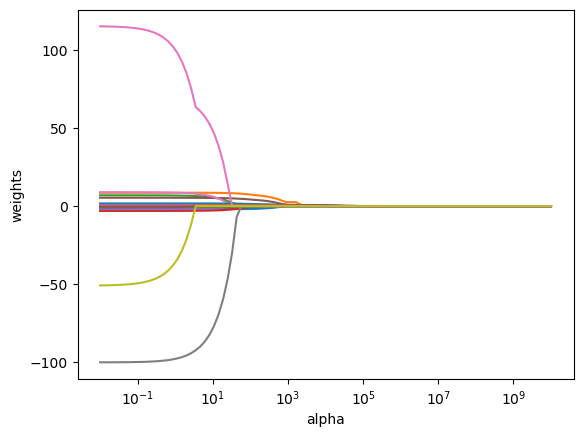

In [493]:
# optimum aplha değerini bulmak için:

lasso = Lasso() 
lambdalar = 10**np.linspace(10, -2, 100) * 0.5
katsayilar = []

for i in lambdalar:
    lasso.set_params(alpha=i)
    lasso.fit(X_train, y_train)
    katsayilar.append(lasso.coef_)

ax = plt.gca()
ax.plot(lambdalar*2, katsayilar)
ax.set_xscale('log')
plt.axis('tight')
plt.xlabel('alpha')
plt.ylabel('weights')

## Tahmin

In [496]:
y_pred = lasso_model.predict(X_test)

In [497]:
np.sqrt(mean_squared_error(y_test, y_pred))

356.754527014877

## Model Tuning

In [508]:
from sklearn.linear_model import LassoCV

In [512]:
lasso_cv_model = LassoCV(alphas=None, 
                         cv=10, 
                         max_iter=10000).fit(X_train, y_train)

In [516]:
lasso_cv_model.alpha_

563.4670501833854

## Final Model

In [519]:
lasso_tuned = Lasso(alpha = lasso_cv_model.alpha_)

In [521]:
lasso_tuned.fit(X_train, y_train)

Lasso(alpha=563.4670501833854)

In [523]:
y_pred = lasso_tuned.predict(X_test)

In [525]:
np.sqrt(mean_squared_error(y_test, y_pred))

373.5957225069794

# ElasticNet Regression

Amaç: Hata kareler toplamını minimize eden katsayıları, bu katsayılara ceza uygulayarak bulmaktır. ElasticNet, L1 ve L2 yaklaşımlarını birleştirir.

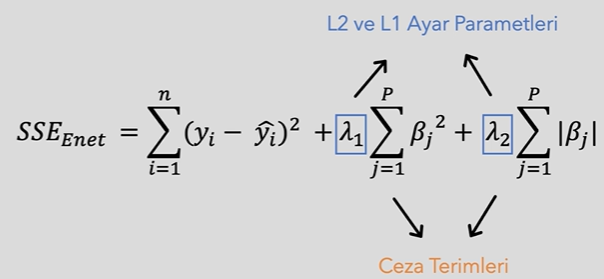

In [530]:
hit = pd.read_csv("Hitters.csv") # bazı basketbolcuların özelliklerini veren veriseti

df = hit.copy()

df = df.dropna()

dms = pd.get_dummies(df[['League', 'Division', 'NewLeague']])

y = df["Salary"] # bağımlı değişkenimizi kaydetmiş olduk

X_ = df.drop(["Salary","League","Division","NewLeague"],axis=1).astype("float")

X = pd.concat([X_, dms[["League_N", "Division_W", "NewLeague_N"]]],axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [532]:
from sklearn.linear_model import ElasticNet

In [534]:
elasticNet_model = ElasticNet().fit(X_train, y_train)

C:\Users\since\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.488e+06, tolerance: 3.899e+03
  model = cd_fast.enet_coordinate_descent(


In [536]:
elasticNet_model.coef_

array([ -1.86256172,   8.70489065,   5.10426375,  -2.89875799,
        -1.28642985,   5.24343682,   6.04480276,  -0.14701495,
        -0.21566628,  -0.7897201 ,   1.80813117,   0.80914508,
        -0.61262382,   0.26816203,   0.27172387,  -0.36530729,
        19.2186222 , -31.16586592,   8.98369938])

In [538]:
elasticNet_model.intercept_

-6.465955602111762

## Tahmin

In [543]:
y_pred = elasticNet_model.predict(X_test)

In [545]:
np.sqrt(mean_squared_error(y_pred, y_test))

357.16765481812445

In [547]:
r2_score(y_test, y_pred)

0.4107022246932692

## Model Tuning

In [550]:
from sklearn.linear_model import ElasticNetCV 

In [552]:
elasticNet_CV_model = ElasticNetCV(cv=10, random_state=0).fit(X_train, y_train)

In [554]:
elasticNet_CV_model.alpha_ # optimum alpha değeri

5230.7647364798695

## Final Model

In [559]:
ElasticNetTuned = ElasticNet(alpha=elasticNet_CV_model.alpha_).fit(X_train, y_train)

In [561]:
y_pred = ElasticNetTuned.predict(X_test)

In [563]:
np.sqrt(mean_squared_error(y_test, y_pred))

394.15280563218795

Özetle makina öğrenimi **aşamaları** şöyledir:

1) Modeli Kurmak (fit etmek)
2) Eğitim Setinde Tahmin (Train Prediction)
3) Eğitim Hatası Hesaplamak
4) Test Setinde Tahmin (Test Prediction)
5) Test Hatası Hesaplamak
6) Model Tuning (Hiperparametre Ayarı)
7) Final Model ve Test Hatası

-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

Açıklamalar:
* Modeli Kurmak (fit etmek): Model, veriyi öğrenmek için bu kısmı kullanır
* Eğitim Setinde Tahmin (Train Prediction): Modelin ne kadar iyi "öğrendiğini" görmek için
* Eğitim Hatası Hesaplamak: Buradaki hata, modelin "ezberleme" seviyesini gösterir. Genelde düşük çıkar, çünkü model zaten bu veriyi gördü.
* Test Setinde Tahmin (Test Prediction): Modelin hiç görmediği veride ne kadar iyi tahmin yaptığını anlamak için. Gerçek dünyada karşımıza çıkacak yeni veriler gibi düşün.
* Test Hatası Hesaplamak: X_test ile tahmin yaptık, doğru cevaplar y_test'te. Buradaki hata, modelin "genel başarı"sını gösterir. Asıl önemli olan budur!
* Model Tuning (Hiperparametre Ayarı): Amaç: Modelin doğruluğunu arttırmak için en iyi parametreleri bulmak (örneğin: kaç bileşen, alfa değeri vs)
* Final Model ve Test Hatası: Model tuning ile en iyi parametreyi bulduk. Şimdi o parametreyle modeli tekrar tüm train setinde eğitiyoruz ve test setinde son kez deneriz

---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

Kodlar:
* Modeli Kurmak (fit etmek): **pls_model = PLSRegression().fit(X_train, y_train)**
* Eğitim Setinde Tahmin (Train Prediction): **y_pred = pls_model.predict(X_train)**
* Eğitim Hatası Hesaplamak: **np.sqrt(mean_squared_error(y_train, y_pred))**
* Test Setinde Tahmin (Test Prediction): **y_pred = pls_model.predict(X_test)**
* Test Hatası Hesaplamak: **np.sqrt(mean_squared_error(y_test, y_pred))**
* Model Tuning (Hiperparametre Ayarı):

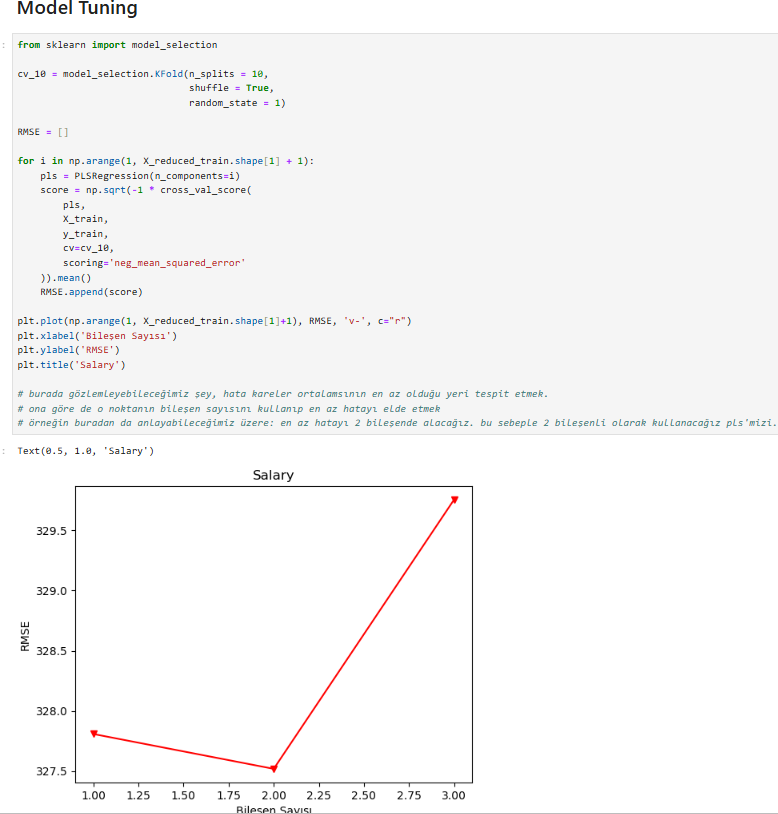
* Final Model ve Test Hatası:

**pls_model = PLSRegression(n_components=2).fit(X_train, y_train)**


**y_pred = pls_model.predict(X_test)**


**np.sqrt(mean_squared_error(y_test, y_pred))**

-------------------------------------------------------------------------------------------------

Kısa Özet:
* Eğitim verileriyle modeli öğret
* Eğitim verileri üzerinde kontrol et (öğrenebildi mi?)
* Test verileri üzerinde değerlendir (genelleyebiliyor mu?)
* Modeli iyileştir (cross-validation, hiperparametre ayarlama)
* Final modeli oluştur ve test verisiyle değerlendir

## Gerçekte özet:

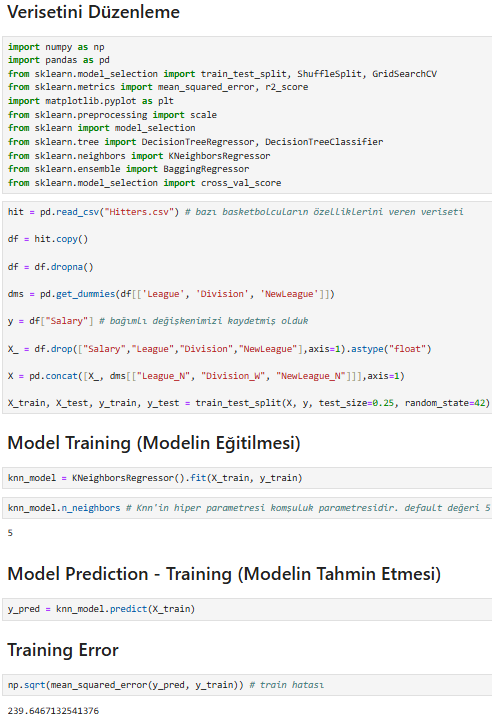

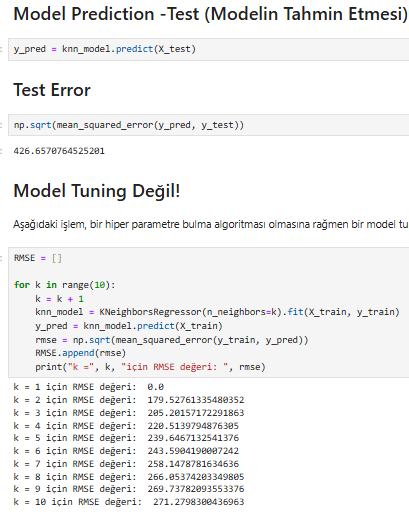

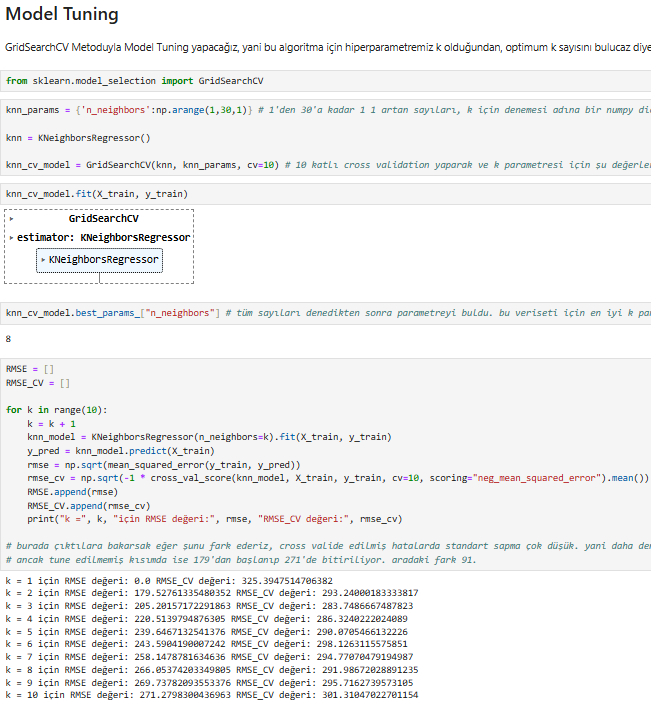

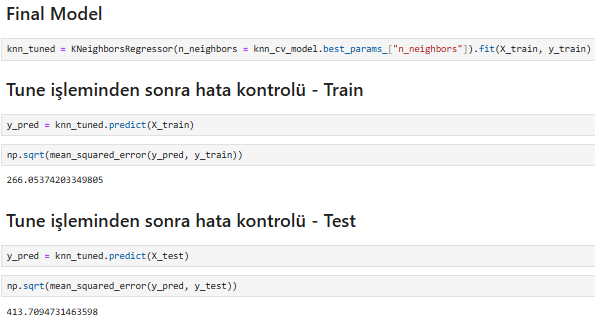